In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

#### Preprocessing:
● Correct the data in the "height" column by replacing it with random numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis. 

In [44]:
df = pd.read_excel('ABC Company.xlsx')
df.to_csv('ABC_Company.csv', index=False)
print(df['Height'].head())
df['Height'] = np.random.randint(150, 181, size=len(df))
print(df['Height'].describe())
df = df.dropna()
print("Missing values in each column:")
print(df.isnull().sum())
within_range = df['Height'].between(150, 180).all()
print(f"\nAll height values within range (150–180): {within_range}")
print("\nData types:")
print(df.dtypes)
df.to_csv('cleaned_data.csv', index=False)

0    2023-02-06 00:00:00
1    2023-06-06 00:00:00
2    2023-05-06 00:00:00
3    2023-05-06 00:00:00
4    2023-10-06 00:00:00
Name: Height, dtype: object
count    458.000000
mean     163.962882
std        9.193801
min      150.000000
25%      156.000000
50%      163.000000
75%      171.750000
max      180.000000
Name: Height, dtype: float64
Missing values in each column:
Name        0
Team        0
Number      0
Position    0
Age         0
Height      0
Weight      0
College     0
Salary      0
dtype: int64

All height values within range (150–180): True

Data types:
Name         object
Team         object
Number        int64
Position     object
Age           int64
Height        int32
Weight        int64
College      object
Salary      float64
dtype: object


#### Analysis Tasks:
● Determine the distribution of employees across each team and calculate
the percentage split relative to the total number of employees.

In [46]:
team_distribution = df['Team'].value_counts().reset_index()
team_distribution.columns = ['Team', 'Employee_Count']
total_employees = len(df)
team_distribution['Percentage'] = (team_distribution['Employee_Count'] / total_employees) * 100
print(team_distribution)

                      Team  Employee_Count  Percentage
0     New Orleans Pelicans              16    4.383562
1          Detroit Pistons              15    4.109589
2   Portland Trail Blazers              15    4.109589
3    Oklahoma City Thunder              14    3.835616
4     Los Angeles Clippers              14    3.835616
5       Philadelphia 76ers              14    3.835616
6          Milwaukee Bucks              14    3.835616
7        Memphis Grizzlies              13    3.561644
8       Washington Wizards              13    3.561644
9        Charlotte Hornets              13    3.561644
10            Phoenix Suns              13    3.561644
11        Sacramento Kings              13    3.561644
12           Brooklyn Nets              13    3.561644
13      Los Angeles Lakers              12    3.287671
14          Boston Celtics              12    3.287671
15   Golden State Warriors              12    3.287671
16           Chicago Bulls              12    3.287671
17        

● Segregate employees based on their positions within the company.

In [52]:
position_distribution = df['Position'].value_counts().reset_index()
position_distribution.columns = ['Position', 'Employee_Count']
print(position_distribution)

  Position  Employee_Count
0       SG              87
1       PF              81
2       PG              76
3       SF              71
4        C              50


● Identify the predominant age group among employees.

In [59]:
bins = [0, 29, 39, 49, 100] 
labels = ['20-29', '30-39', '40-49', '50+']  
df['Age_Group'] = pd.cut(df['Age'],bins=bins, labels=labels, right=True)
age_group_counts = df['Age_Group'].value_counts().reset_index()
age_group_counts.columns = ['Age_Group', 'Employee_Count']
predominant_group = age_group_counts.loc[age_group_counts['Employee_Count'].idxmax()]
print("Age group distribution:")
print(age_group_counts)
print("\nPredominant age group:")
print(predominant_group)

Age group distribution:
  Age_Group  Employee_Count
0     20-29             281
1     30-39              82
2     40-49               2
3       50+               0

Predominant age group:
Age_Group         20-29
Employee_Count      281
Name: 0, dtype: object


● Discover which team and position have the highest salary expenditure.

In [63]:
team_salary = df.groupby('Team')['Salary'].sum().reset_index()
team_salary = team_salary.sort_values(by='Salary', ascending=False)
highest_team = team_salary.iloc[0]
position_salary = df.groupby('Position')['Salary'].sum().reset_index()
position_salary = position_salary.sort_values(by='Salary', ascending=False)
highest_position = position_salary.iloc[0]

print("Team with highest salary expenditure:")
print(highest_team)
print("\nPosition with highest salary expenditure:")
print(highest_position)

Team with highest salary expenditure:
Team      Los Angeles Clippers
Salary              93906914.0
Name: 12, dtype: object

Position with highest salary expenditure:
Position             PG
Salary      373621258.0
Name: 2, dtype: object


● Investigate if there's any correlation between age and salary, and represent it visually.

Correlation between Age and Salary: 0.16


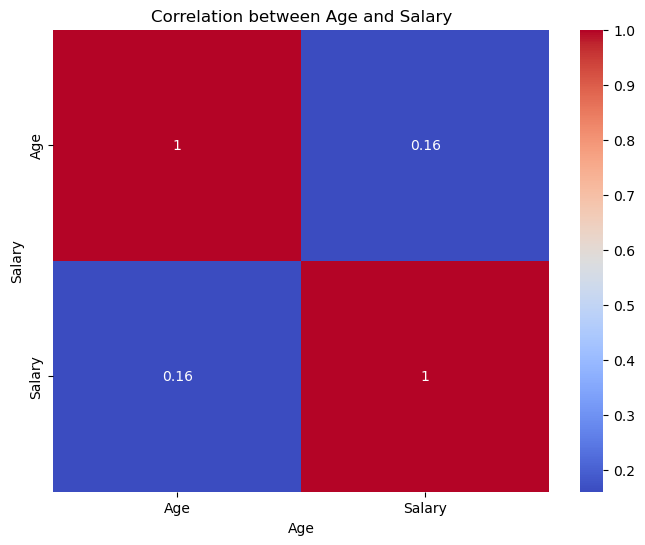

In [72]:
correlation = df['Age'].corr(df['Salary'])
print(f"Correlation between Age and Salary: {correlation:.2f}")
corr_matrix = df[['Age', 'Salary']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True,cmap='coolwarm')
plt.title("Correlation between Age and Salary")
plt.show()

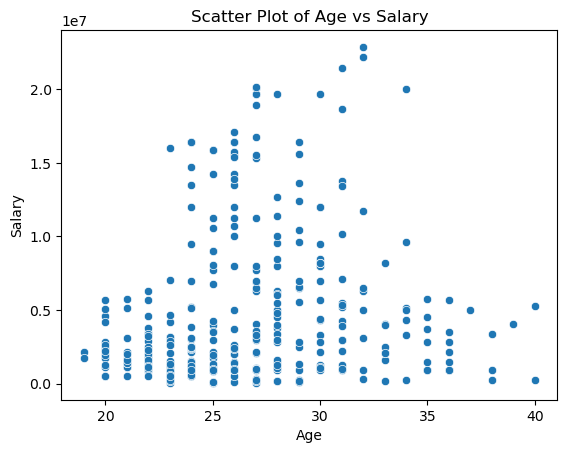

In [74]:
sns.scatterplot(x='Age', y='Salary', data=df)
plt.title('Scatter Plot of Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()

#### Graphical Representation:
● For each of the five analysis tasks above, create appropriate visualizations to present your findings effectively.

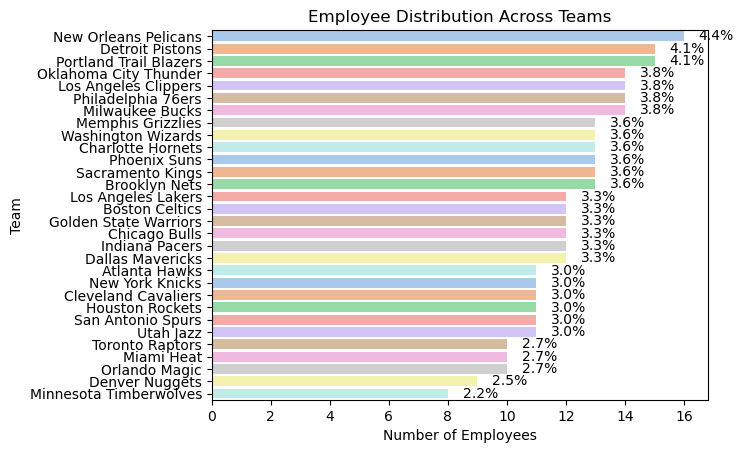

In [110]:
#Employee Distribution Across Teams
ax = sns.countplot(
    y='Team', 
    data=df, 
    order=df['Team'].value_counts().index, 
    palette="pastel"
)
total = len(df)
for p in ax.patches:
    percentage = f'{(p.get_width()/total)*100:.1f}%'
    ax.text(p.get_width() + 0.5,  
            p.get_y() + p.get_height()/2,  
            percentage, 
            va='center')  
plt.title('Employee Distribution Across Teams')
plt.xlabel('Number of Employees')
plt.ylabel('Team')
plt.show()


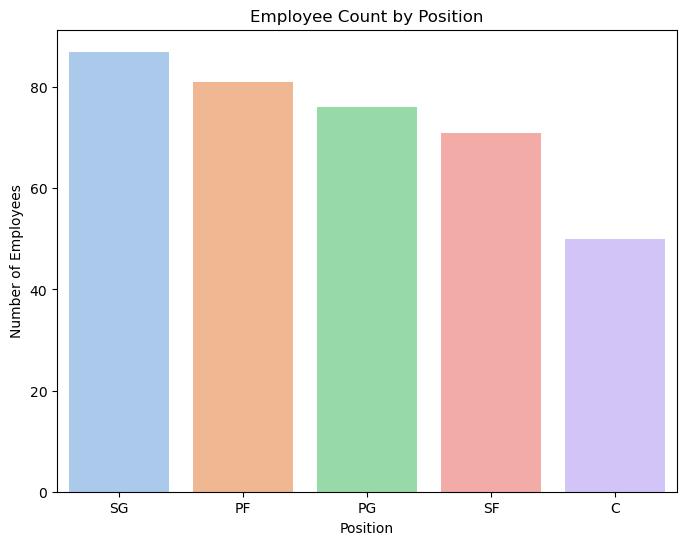

In [112]:
#Employee Segregation by Position
plt.figure(figsize=(8,6))
sns.barplot(x='Position', y='Employee_Count', data=position_distribution, palette="pastel")
plt.title('Employee Count by Position')
plt.ylabel('Number of Employees')
plt.xlabel('Position')
plt.show()

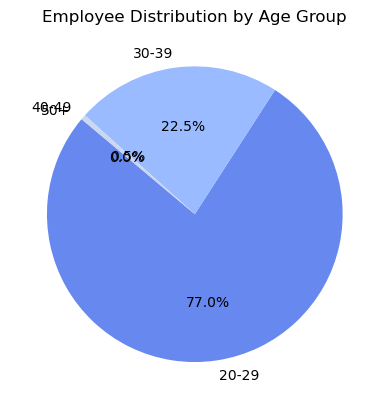

In [111]:
#predominant age group among employees.
plt.pie(age_group_counts['Employee_Count'],
        labels=age_group_counts['Age_Group'],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette("coolwarm"))
plt.title('Employee Distribution by Age Group')
plt.show()
# Hence predominant age group the pie chart is in the age group 20-29

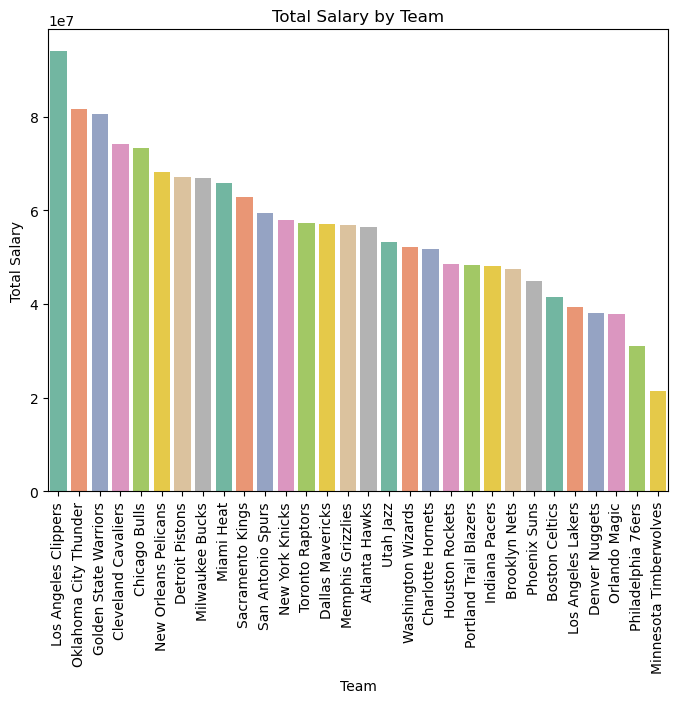

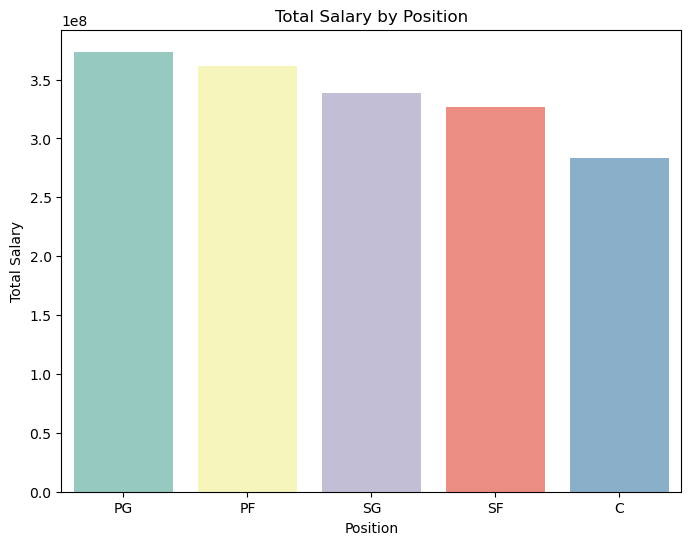

In [101]:
#Salary Expenditure by Team and Position
plt.figure(figsize=(8,6))
sns.barplot(x='Team', y='Salary', data=team_salary, palette="Set2")
plt.title('Total Salary by Team')
plt.ylabel('Total Salary')
plt.xlabel('Team')
plt.xticks(rotation = 90)
plt.show()


plt.figure(figsize=(8,6))
sns.barplot(x='Position', y='Salary', data=position_salary, palette="Set3")
plt.title('Total Salary by Position')
plt.ylabel('Total Salary')
plt.xlabel('Position')
plt.show()

<Figure size 800x600 with 0 Axes>

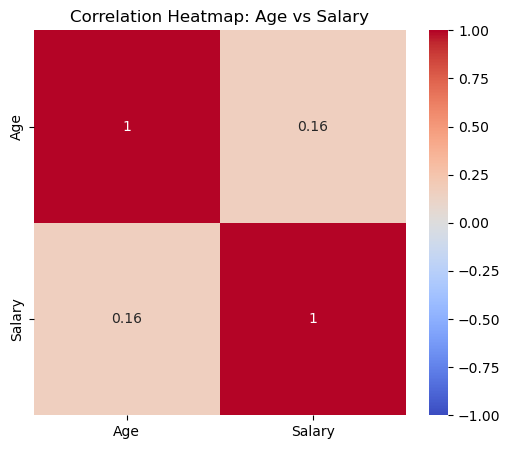

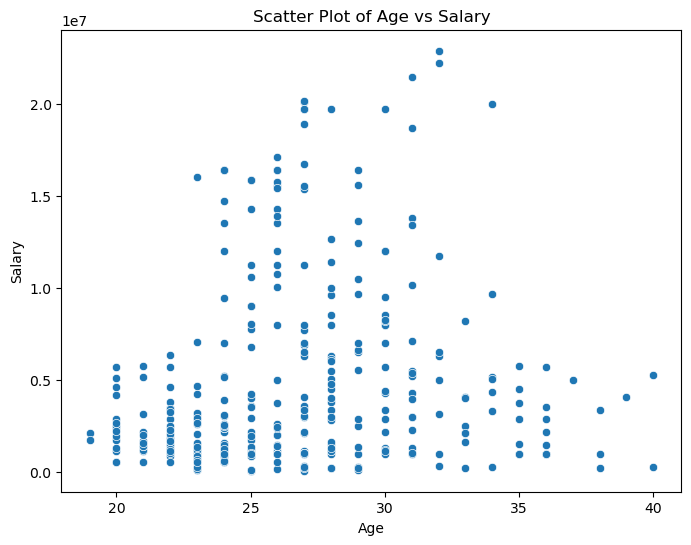

In [108]:
#Heatmap(correlation b/w age and salary)
plt.figure(figsize=(6,5))
corr_matrix = df[['Age', 'Salary']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Age vs Salary")
plt.show()

#Scatter plot with regression line
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='Salary',data=df)
plt.title('Scatter Plot of Age vs Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()

**Data Story: Employee Distribution Across Teams**

New Orleans Pelicans have the highest represenation with approximately 4.38% of total employees, followed closely by the Detroit Pistons and Portland Trail Blazers, each contributing around 4.1%.Teams like the Minnesota Timberwolves (2.19%) and Denver Nuggets (2.46%) have the lowest employee representation, indicating no of employees.The visualization displays this insight by a countplot with Teams in y-axis and No of employees in the x-axis.Here,with most teams showing comparable employee counts, creating a consistent bar height across the plot.

**Data Story: Employee Segregation by Position**

The distribution by position reveals that the SG role is the most common, with 87 employees.Then followed by PF with 81 employees and PG with 76 employees, showing that these positions form the core structure of most teams.SF position displays with 71 employees, while the Center C position records the lowest representation at 50 employees.Bar chart visualization shows the distribution clearly and showing a gradual decline from SG to C.Highlighting that teams tend to prioritize SG.

**Data Story: Predominant Age Group**

The pie chart displays that the 20–29 age group mostly dominates the workforce, with 281 employees, accounting for the majority of the total staff. The next age group, 30–39, includes only 82 employees, while the 40–49 group has just 2 employees, and there are no employees aged 50 or above. This trend showa that the company’s workforce is predominantly youngsters.The older age groups are very limited, so senior employees may limited.The pie chart visualization reinforces this observation by clearly showing the percentage distribution of each age group.

**Data Story: Salary Expenditure by Team and Position**

The analysis of salary expenditure reveals that the Los Angeles Clippers account for the highest total team salary, amounting to 93,906,91.When examining salary by position, the PG role has the highest total salary expenditure at 373,621,258.These findings shows that both team  and positions h influence overall salary spending.The bar charts visualization effectively the relationship between team and salary. The total salary expenditure decreases from the Los Angeles Clippers (highest) to the Minnesota Timberwolves (lowest), highlighting differences in team investment. Similarly, the chart representing position and salary shows a decline from PG to Centers C.

**Data Story: Correlation Between Age and Salary**

The correlation between age and salary is 0.16, indicating a weak positive relationship.The scatter plot and heatmap visualizations displays this observation, showing that salary values spread across different age group, with no clear upward or downward trend. 